# Polynomial Regression

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

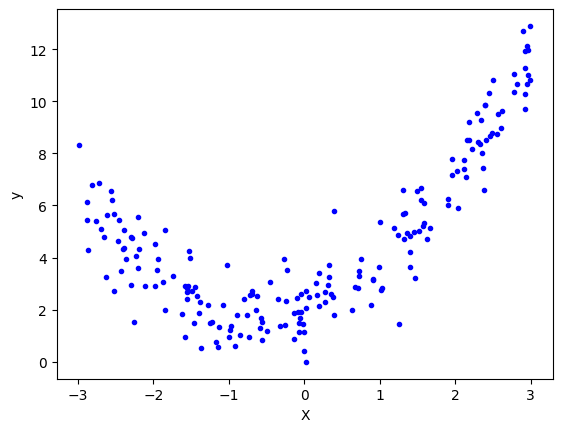

In [53]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 2)

In [55]:
model = LinearRegression()

In [56]:
model.fit(X_train,y_train)

LinearRegression()

In [57]:
y_pred = model.predict(X_train)
r2_score(y_train,y_pred)

0.3421657913442845

In [58]:
y_pred1 = model.predict(X_test)
r2_score(y_test,y_pred1)

0.5015865844285775

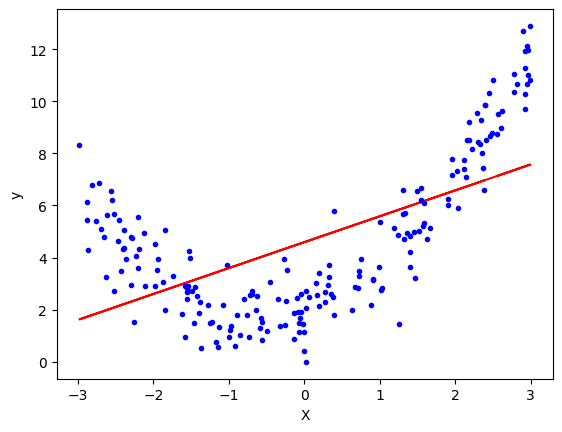

In [59]:
plt.plot(X_train,model.predict(X_train),color='red')
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [60]:
poly = PolynomialFeatures(degree=2 , include_bias = True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)


In [61]:
print(X_train[0])
print(X_train_trans[0])

[2.38882285]
[1.         2.38882285 5.7064746 ]


In [62]:
model = LinearRegression()
model.fit(X_train_trans , y_train)

LinearRegression()

In [63]:
y_pred = model.predict(X_test_trans)

In [64]:
r2_score(y_test,y_pred)

0.9060656898000771

In [65]:
print(model.coef_)

[[0.         0.88670307 0.80620563]]


In [66]:
print(model.intercept_)

[2.06692023]


In [67]:
X_new = np.linspace(-3 , 3 , 200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = model.predict(X_new_poly)

<function matplotlib.pyplot.show(close=None, block=None)>

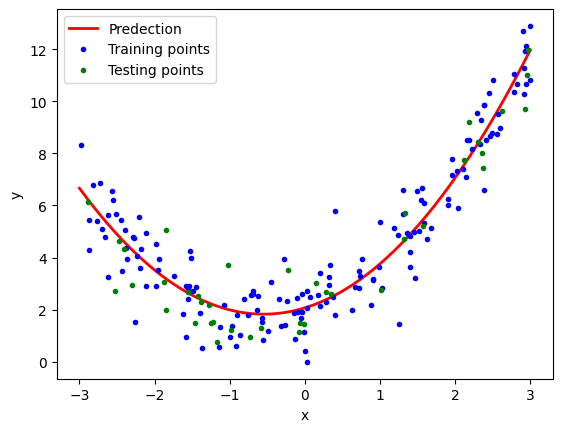

In [68]:
plt.plot(X_new,y_new,'r-',linewidth=2,label="Predection")
plt.plot(X_train,y_train,'b.',label="Training points")
plt.plot(X_test,y_test,"g.",label="Testing points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show


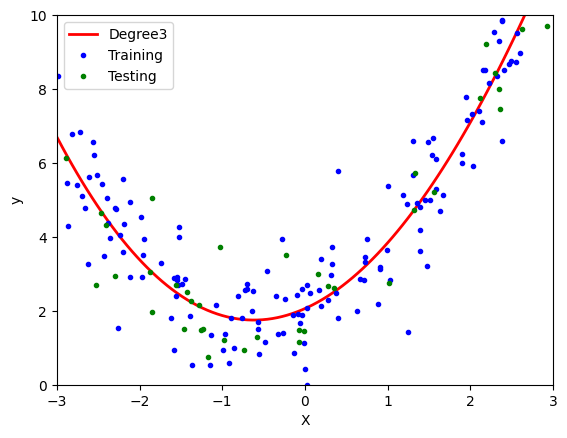

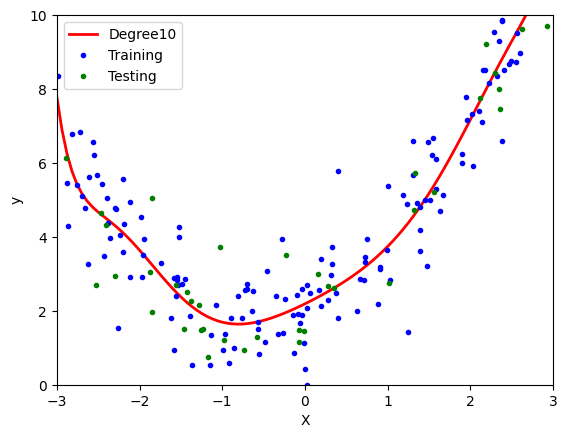

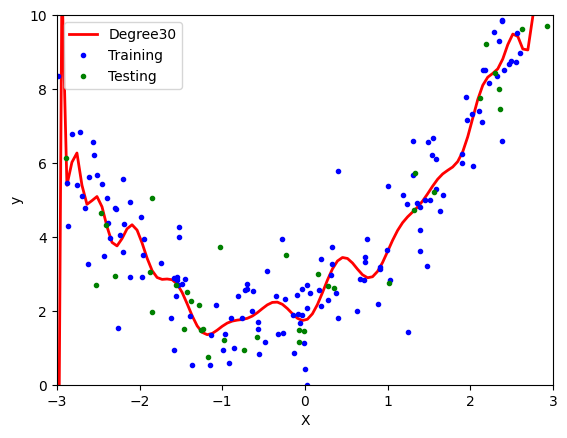

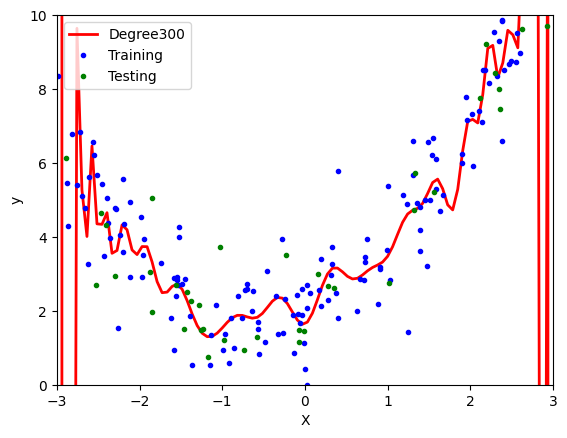

In [69]:
def plot_polynomial_regression(degree):
    X_new = np.linspace(-3 , 3 , 100).reshape(100,1)
   
    polybig_features = PolynomialFeatures(degree=degree , include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    
    polynomial_model = Pipeline([
           ("poly_features",polybig_features),
           ("std_scaler",std_scaler),
           ("lin_reg",lin_reg),
    ])
    polynomial_model.fit(X,y)
    y_newbig = polynomial_model.predict(X_new)

    plt.plot(X_new , y_newbig , 'r' , label = "Degree" + str(degree) , linewidth = 2)
    plt.plot(X_train,y_train,'b.',linewidth=3 , label="Training")
    plt.plot(X_test,y_test,'g.',linewidth=3 , label = "Testing")
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3 , 3 ,0 , 10])
    plt.show()



plot_polynomial_regression(3) # normal
plot_polynomial_regression(10) # overfitting started
plot_polynomial_regression(30) # extreme overfitting
plot_polynomial_regression(300) # most extreme overfitting

     
    

In [70]:
z = np.array([[[1,2,3,] ,
             [4,5,6 ],
             [7,8,9]]])
z


array([[[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]])

In [71]:
z.ndim

3

In [72]:
z.shape

(1, 3, 3)

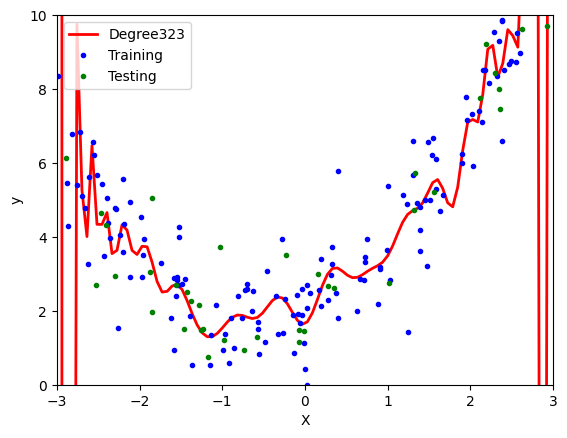

In [73]:
plot_polynomial_regression(323)